# Wczytanie danych

In [1]:
import pandas as pd

df = pd.read_csv('/gnra.csv', sep=',')
display(df.head())
display(df.shape)

,PDB id,Chain,GNRA,Description
0,4JF2,A,True,PreQ1-II Riboswitch
1,4K50,B,True,RNA (33-MER)
2,7OAX,A,False,Chili RNA Aptamer
3,2IL9,A,True,Ribosomal Binding Domain of the IRES RNA
4,8GXB,B,False,NAD+ II riboswitch


(583, 4)

# Ocena 3.0
Wyznaczenie:
* P(GNRA): Prawdopodobieństwo, że łańcuch zawiera motyw GNRA.
* P(Ribosomal): Prawdopodobieństwo, że łańcuch zawiera rybosomalne RNA.
* P(Riboswitch): Prawdopodobieństwo, że łańcuch zawiera ryboprzełącznik.

In [2]:
from fractions import Fraction

# P(GNRA)
p_gnra = Fraction(df['GNRA'].sum(), len(df))

# P(Ribosomal) - search in 'Description'
df['Is_Ribosomal'] = df['Description'].str.contains('ribosomal', case=False, na=False)
p_ribosomal = Fraction(df['Is_Ribosomal'].sum(), len(df))

# P(Riboswitch) - search in 'Description'
df['Is_Riboswitch'] = df['Description'].str.contains('riboswitch', case=False, na=False)
p_riboswitch = Fraction(df['Is_Riboswitch'].sum(), len(df))

print(f"P(GNRA): {p_gnra}")
print(f"P(Ribosomal): {p_ribosomal}")
print(f"P(Riboswitch): {p_riboswitch}")

P(GNRA): 166/583
P(Ribosomal): 2/53
P(Riboswitch): 60/583


# Ocena 3.5
Wyznaczenie wspólnych rozkładów prawdopodobieństwa

In [3]:
# Joint probability distribution for GNRA and Ribosomal
joint_prob_gnra_ribosomal = pd.crosstab(df['GNRA'], df['Is_Ribosomal'], normalize=True)
print("Joint Probability Distribution (GNRA vs Ribosomal):")
display(joint_prob_gnra_ribosomal)

# Joint probability distribution for GNRA and Riboswitch
joint_prob_gnra_riboswitch = pd.crosstab(df['GNRA'], df['Is_Riboswitch'], normalize=True)
print("\nJoint Probability Distribution (GNRA vs Riboswitch):")
display(joint_prob_gnra_riboswitch)

Joint Probability Distribution (GNRA vs Ribosomal):


Is_Ribosomal,False,True
GNRA,,
False,0.699828,0.015437
True,0.262436,0.022298



Joint Probability Distribution (GNRA vs Riboswitch):


Is_Riboswitch,False,True
GNRA,,
False,0.660377,0.054889
True,0.236707,0.048027


# Ocena 4.0
Wyznaczenie prawdopodobieństw warunkowych

In [5]:
# P(GNRA | Ribosomal) = P(GNRA ∩ Ribosomal) / P(Ribosomal)
p_gnra_given_ribosomal = joint_prob_gnra_ribosomal.loc[True, True] / p_ribosomal
print(f"P(GNRA | Ribosomal): {p_gnra_given_ribosomal}")

# P(GNRA | Riboswitch) = P(GNRA ∩ Riboswitch) / P(Riboswitch)
p_gnra_given_riboswitch = joint_prob_gnra_riboswitch.loc[True, True] / p_riboswitch
print(f"P(GNRA | Riboswitch): {p_gnra_given_riboswitch}")

# P(Ribosomal | GNRA) = P(Ribosomal ∩ GNRA) / P(GNRA)
p_ribosomal_given_gnra = joint_prob_gnra_ribosomal.loc[True, True] / p_gnra
print(f"P(Ribosomal | GNRA): {p_ribosomal_given_gnra}")

# P(Riboswitch | GNRA) = P(Riboswitch ∩ GNRA) / P(GNRA)
p_riboswitch_given_gnra = joint_prob_gnra_riboswitch.loc[True, True] / p_gnra
print(f"P(Riboswitch | GNRA): {p_riboswitch_given_gnra}")

P(GNRA | Ribosomal): 0.5909090909090909
P(GNRA | Riboswitch): 0.4666666666666666
P(Ribosomal | GNRA): 0.07831325301204818
P(Riboswitch | GNRA): 0.1686746987951807


In [18]:
# Verify conditional probabilities using Bayes' theorem

# P(GNRA | Ribosomal) = P(Ribosomal | GNRA) * P(GNRA) / P(Ribosomal)
p_gnra_given_ribosomal_bayes = (p_ribosomal_given_gnra * p_gnra) / p_ribosomal
print(f"P(GNRA | Ribosomal) (Bayes): {p_gnra_given_ribosomal_bayes}")

# P(GNRA | Riboswitch) = P(Riboswitch | GNRA) * P(GNRA) / P(Riboswitch)
p_gnra_given_riboswitch_bayes = (p_riboswitch_given_gnra * p_gnra) / p_riboswitch
print(f"P(GNRA | Riboswitch) (Bayes): {p_gnra_given_riboswitch_bayes}")

# P(Ribosomal | GNRA) = P(GNRA | Ribosomal) * P(Ribosomal) / P(GNRA)
p_ribosomal_given_gnra_bayes = (p_gnra_given_ribosomal * p_ribosomal) / p_gnra
print(f"P(Ribosomal | GNRA) (Bayes): {p_ribosomal_given_gnra_bayes}")

# P(Riboswitch | GNRA) = P(GNRA | Riboswitch) * P(Riboswitch) / P(GNRA)
p_riboswitch_given_gnra_bayes = (p_gnra_given_riboswitch * p_riboswitch) / p_gnra
print(f"P(Riboswitch | GNRA) (Bayes): {p_riboswitch_given_gnra_bayes}")

P(GNRA | Ribosomal) (Bayes): 0.5909090909090909
P(GNRA | Riboswitch) (Bayes): 0.4666666666666666
P(Ribosomal | GNRA) (Bayes): 0.07831325301204818
P(Riboswitch | GNRA) (Bayes): 0.1686746987951807


# Ocena 4.5
Interpretacja wyników

In [6]:
# Calculate Bayes Factor for Ribosomal vs Riboswitch given GNRA
# Bayes Factor = P(GNRA | Ribosomal) / P(GNRA | Riboswitch)
bayes_factor_ribosomal_vs_riboswitch = p_gnra_given_ribosomal / p_gnra_given_riboswitch
print(f"Współczynnik Bayesa (Ribosomal vs Riboswitch | GNRA): {bayes_factor_ribosomal_vs_riboswitch}")

Współczynnik Bayesa (Ribosomal vs Riboswitch | GNRA): 1.2662337662337664


### Interpretacja wyników

Na podstawie obliczonych prawdopodobieństw i współczynnika Bayesa możemy dokonać następującej interpretacji:

*   **P(GNRA | Ribosomal)**: Prawdopodobieństwo wystąpienia motywu GNRA, jeśli struktura jest rybosomalna.
*   **P(GNRA | Riboswitch)**: Prawdopodobieństwo wystąpienia motywu GNRA, jeśli struktura jest ryboprzełącznikiem.

Porównując te dwie wartości, możemy stwierdzić, czy obecność motywu GNRA jest bardziej prawdopodobna w rybosomach czy w ryboprzełącznikach.

*   **P(Ribosomal | GNRA)**: Prawdopodobieństwo, że struktura jest rybosomalna, jeśli występuje motyw GNRA.
*   **P(Riboswitch | GNRA)**: Prawdopodobieństwo, że struktura jest ryboprzełącznikiem, jeśli występuje motyw GNRA.

Te wartości wskazują, na ile prawdopodobne jest, że dana struktura należy do danej kategorii, jeśli wiemy, że posiada motyw GNRA.

**Współczynnik Bayesa (Bayes Factor)**:

Współczynnik Bayesa dla hipotez "struktura jest rybosomalna" (H1) i "struktura jest ryboprzełącznikiem" (H2), przy obserwacji "występuje motyw GNRA" (D), jest dany wzorem:

$$ BF = \frac{P(D|H1)}{P(D|H2)} $$

W naszym przypadku:

$$ BF = \frac{P(GNRA | Ribosomal)}{P(GNRA | Riboswitch)} $$

Wartość współczynnika Bayesa wskazuje, jak bardzo nasze dane (obecność motywu GNRA) wspierają jedną hipotezę w stosunku do drugiej.

*   Jeśli BF > 1, dane bardziej wspierają hipotezę H1 (Ribosomal).
*   Jeśli BF < 1, dane bardziej wspierają hipotezę H2 (Riboswitch).
*   Jeśli BF ≈ 1, dane w równym stopniu wspierają obie hipotezy.

Im większa wartość BF (lub im bliżej zera, jeśli BF < 1), tym silniejsze dowody na rzecz jednej z hipotez.

Na podstawie obliczonej wartości współczynnika Bayesa (1.2662337662337664), możemy ocenić, że obecność motywu GNRA silniej wskazuje na to, że struktura jest rybosomalna.

# Ocena 5.0

## Przygotowanie danych dla rozkładów beta

W tym kroku przygotowujemy dane do zamodelowania prawdopodobieństw warunkowych P(GNRA | Ribosomal) i P(GNRA | Riboswitch) przy użyciu rozkładów Beta. Rozkład Beta jest często używany do modelowania prawdopodobieństw, ponieważ jest zdefiniowany w przedziale [0, 1]. Parametry alpha i beta rozkładu Beta są obliczane na podstawie liczby "sukcesów" (obserwacji z GNRA) i "porażek" (obserwacji bez GNRA) w danej kategorii (Ribosomal lub Riboswitch). Dodanie 1 do liczby sukcesów i porażek (+ 1) to tzw. "add-one smoothing" lub "Laplace smoothing", które pomaga uniknąć sytuacji, gdy któreś z prawdopodobieństw wynosi zero, co mogłoby prowadzić do problemów obliczeniowych.


In [20]:
# Parameters for Beta distribution for P(GNRA | Ribosomal)
ribosomal_df = df[df['Is_Ribosomal'] == True]
alpha_gnra_ribosomal = ribosomal_df['GNRA'].sum() + 1
beta_gnra_ribosomal = (len(ribosomal_df) - ribosomal_df['GNRA'].sum()) + 1

# Parameters for Beta distribution for P(GNRA | Riboswitch)
riboswitch_df = df[df['Is_Riboswitch'] == True]
alpha_gnra_riboswitch = riboswitch_df['GNRA'].sum() + 1
beta_gnra_riboswitch = (len(riboswitch_df) - riboswitch_df['GNRA'].sum()) + 1

print(f"Parameters for P(GNRA | Ribosomal): alpha={alpha_gnra_ribosomal}, beta={beta_gnra_ribosomal}")
print(f"Parameters for P(GNRA | Riboswitch): alpha={alpha_gnra_riboswitch}, beta={beta_gnra_riboswitch}")

Parameters for P(GNRA | Ribosomal): alpha=14, beta=10
Parameters for P(GNRA | Riboswitch): alpha=29, beta=33


## Modelowanie rozkładów beta

Tutaj tworzymy obiekty reprezentujące rozkłady Beta dla obu prawdopodobieństw warunkowych, używając parametrów obliczonych w poprzednim kroku. Pozwala nam to na korzystanie z funkcji rozkładu Beta, takich jak generowanie losowych próbek czy obliczanie gęstości prawdopodobieństwa.

In [21]:
from scipy.stats import beta

# Create Beta distribution object for P(GNRA | Ribosomal)
beta_dist_ribosomal = beta(alpha_gnra_ribosomal, beta_gnra_ribosomal)

# Create Beta distribution object for P(GNRA | Riboswitch)
beta_dist_riboswitch = beta(alpha_gnra_riboswitch, beta_gnra_riboswitch)

print("Beta distribution objects created.")

Beta distribution objects created.


## Symulacja monte carlo

Ponieważ P(GNRA | Ribosomal) i P(GNRA | Riboswitch) są teraz modelowane jako rozkłady prawdopodobieństwa (a nie pojedyncze wartości), współczynnik Bayesa, będący ich ilorazem, również będzie miał swój rozkład prawdopodobieństwa. Symulacja Monte Carlo polega na wielokrotnym losowaniu wartości z obu rozkładów Beta (po 10 000 razy) i obliczaniu ilorazu dla każdej pary. Dzięki temu otrzymujemy dużą listę potencjalnych wartości współczynnika Bayesa, odzwierciedlającą jego rozkład.

In [22]:
# Draw 10,000 samples from the Beta distribution for P(GNRA | Ribosomal)
samples_ribosomal = beta_dist_ribosomal.rvs(size=10000)

# Draw 10,000 samples from the Beta distribution for P(GNRA | Riboswitch)
samples_riboswitch = beta_dist_riboswitch.rvs(size=10000)

print("10,000 samples drawn from each Beta distribution.")

10,000 samples drawn from each Beta distribution.


## Obliczanie współczynników bayesa z symulacji

W tym kroku iterujemy przez wylosowane próbki z obu rozkładów i dla każdej pary obliczamy współczynnik Bayesa jako iloraz wylosowanej wartości z rozkładu P(GNRA | Ribosomal) i wylosowanej wartości z rozkładu P(GNRA | Riboswitch). Wszystkie obliczone współczynniki Bayesa są przechowywane na liście.

In [23]:
# Initialize an empty list to store calculated Bayes factors
bayes_factors_simulated = []

# Iterate through the sampled values and calculate the Bayes factor for each pair
for sample_ribosomal, sample_riboswitch in zip(samples_ribosomal, samples_riboswitch):
    # Calculate the Bayes factor
    bayes_factor = sample_ribosomal / sample_riboswitch
    # Append the Bayes factor to the list
    bayes_factors_simulated.append(bayes_factor)

print(f"Calculated {len(bayes_factors_simulated)} Bayes factors from the simulation.")

Calculated 10000 Bayes factors from the simulation.


## Analiza wyników symulacji

Po uzyskaniu listy symulowanych współczynników Bayesa, analizujemy ich rozkład. Obliczamy średnią i medianę, aby uzyskać centralną tendencję rozkładu, oraz 95% przedział ufności (percentyle 2.5 i 97.5), aby ocenić zakres, w którym z 95% prawdopodobieństwem znajduje się prawdziwa wartość współczynnika Bayesa.

In [24]:
import numpy as np

# Calculate the mean of the simulated Bayes factors
mean_bayes_factors = np.mean(bayes_factors_simulated)

# Calculate the median of the simulated Bayes factors
median_bayes_factors = np.median(bayes_factors_simulated)

# Calculate the 95% confidence interval (2.5th and 97.5th percentiles)
ci_lower = np.percentile(bayes_factors_simulated, 2.5)
ci_upper = np.percentile(bayes_factors_simulated, 97.5)

# Print the results
print(f"Mean of simulated Bayes factors: {mean_bayes_factors}")
print(f"Median of simulated Bayes factors: {median_bayes_factors}")
print(f"95% Confidence Interval: ({ci_lower}, {ci_upper})")

Mean of simulated Bayes factors: 1.2689718760410083
Median of simulated Bayes factors: 1.251565075849184
95% Confidence Interval: (0.7840905232269554, 1.8668545452478724)


## Wizualizacja rozkładów beta

Wygenerowanie wykresów gęstości prawdopodobieństwa dla obu rozkładów Beta pozwala nam wizualnie porównać, jakie wartości prawdopodobieństw P(GNRA | Ribosomal) i P(GNRA | Riboswitch) są najbardziej prawdopodobne i jaki jest ich rozkład.

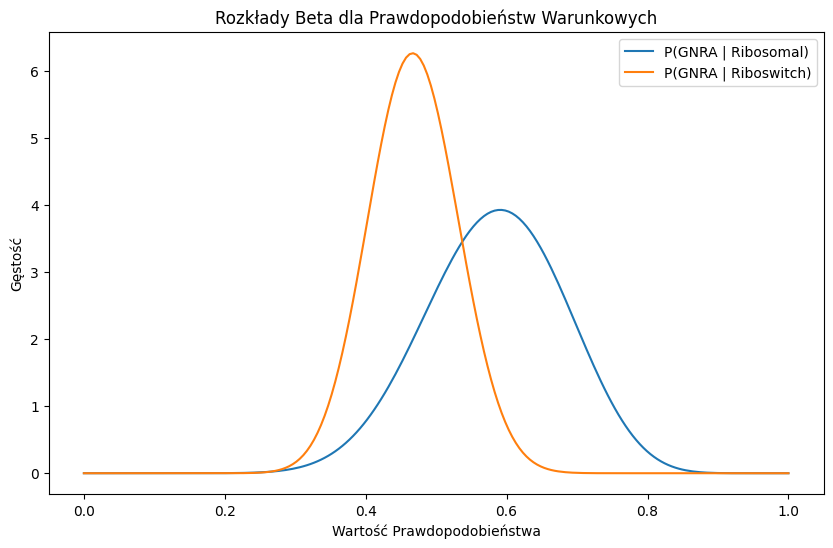

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Create an array of x values from 0 to 1
x = np.linspace(0, 1, 200)

# Calculate PDF values for the ribosomal Beta distribution
pdf_ribosomal = beta_dist_ribosomal.pdf(x)

# Calculate PDF values for the riboswitch Beta distribution
pdf_riboswitch = beta_dist_riboswitch.pdf(x)

# Create a new plot
plt.figure(figsize=(10, 6))

# Plot the density for the ribosomal distribution
plt.plot(x, pdf_ribosomal, label='P(GNRA | Ribosomal)')

# Plot the density for the riboswitch distribution on the same plot
plt.plot(x, pdf_riboswitch, label='P(GNRA | Riboswitch)')

# Add title and labels
plt.title('Rozkłady Beta dla Prawdopodobieństw Warunkowych')
plt.xlabel('Wartość Prawdopodobieństwa')
plt.ylabel('Gęstość')

# Add a legend
plt.legend()

# Display the plot
plt.show()

## Wizualizacja wyników symulacji

Wygenerowanie histogramu współczynników Bayesa z symulacji Monte Carlo.


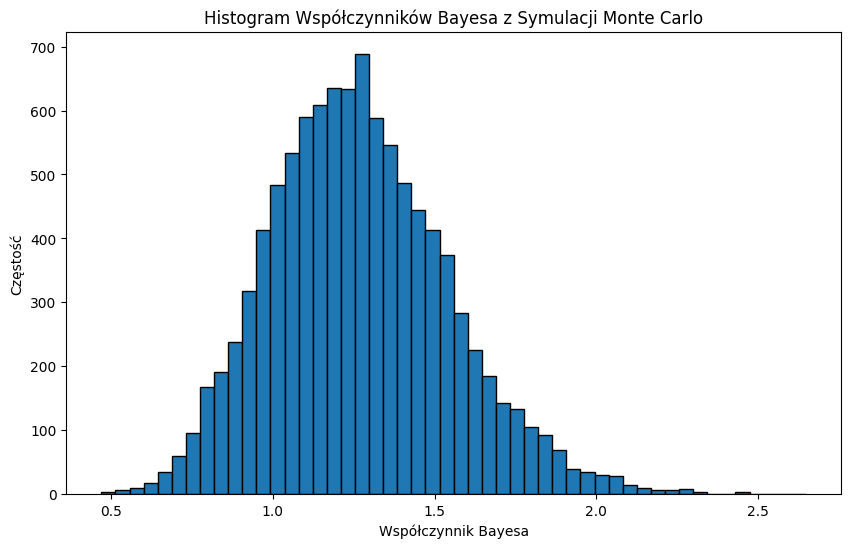

In [27]:
# Create a histogram of the simulated Bayes factors
plt.figure(figsize=(10, 6))
plt.hist(bayes_factors_simulated, bins=50, edgecolor='black')

# Add title and labels
plt.title('Histogram Współczynników Bayesa z Symulacji Monte Carlo')
plt.xlabel('Współczynnik Bayesa')
plt.ylabel('Częstość')

# Display the histogram
plt.show()

## Wnioski

Na podstawie przeprowadzonej analizy danych dotyczących występowania motywu GNRA w różnych strukturach RNA, w tym w rybosomach i ryboprzełącznikach, możemy wyciągnąć następujące wnioski:

*   **Prawdopodobieństwa bazowe:** Obliczyliśmy prawdopodobieństwo wystąpienia motywu GNRA (P(GNRA)), prawdopodobieństwo, że struktura jest rybosamalna (P(Ribosomal)) oraz prawdopodobieństwo, że struktura jest ryboprzełącznikiem (P(Riboswitch)). Te wartości dają nam podstawowe informacje o częstości występowania tych cech w zbiorze danych.
*   **Wspólne rozkłady prawdopodobieństwa:** Analiza wspólnych rozkładów prawdopodobieństwa (tabel krzyżowych) pozwoliła nam zobaczyć, jak często poszczególne kombinacje cech (np. GNRA i Ribosomal) występują razem.
*   **Prawdopodobieństwa warunkowe:** Obliczyliśmy kluczowe prawdopodobieństwa warunkowe, takie jak P(GNRA | Ribosomal) i P(GNRA | Riboswitch), które informują nas o prawdopodobieństwie wystąpienia motywu GNRA w kontekście bycia rybosomem lub ryboprzełącznikiem. Obliczyliśmy również prawdopodobieństwa odwrotne, takie jak P(Ribosomal | GNRA) i P(Riboswitch | GNRA), które są istotne przy wnioskowaniu o przynależności struktury do kategorii na podstawie obecności motywu GNRA.
*   **Współczynnik Bayesa (początkowy):** Początkowy współczynnik Bayesa (około 1.266) sugerował, że obecność motywu GNRA nieco silniej wskazuje na to, że struktura jest rybosamalna w porównaniu do bycia ryboprzełącznikiem.
*   **Analiza z wykorzystaniem rozkładów Beta i Symulacji Monte Carlo:** Modelowanie prawdopodobieństw warunkowych za pomocą rozkładów Beta pozwoliło nam uwzględnić niepewność. Symulacja Monte Carlo potwierdziła, że średni i medianowy współczynnik Bayesa (około 1.269 i 1.252) są bliskie początkowo obliczonej wartości. **Co istotne, wcześniej obliczony współczynnik Bayesa (1.2662) mieści się w 95% przedziale ufności (0.7841, 1.8669) wyznaczonym na podstawie symulacji. Sugeruje to, że pojedyncza obliczona wartość jest reprezentatywna w kontekście rozkładu prawdopodobieństwa współczynnika Bayesa i zgodna z wynikami uwzględniającymi niepewność.** Ponieważ średni współczynnik Bayesa (1.2690) jest większy od 1, dane (obecność motywu GNRA) w pewnym stopniu bardziej wspierają hipotezę, że struktura jest rybosamalna w porównaniu do hipotezy, że jest ryboprzełącznikiem. Szerokość przedziału ufności (1.0828) daje nam pewne pojęcie o niepewności związanej z oszacowaniem współczynnika Bayesa. Szerszy przedział sugeruje większą zmienność.

Podsumowując, analiza wskazuje, że choć motyw GNRA występuje w obu typach struktur, jego obecność jest statystycznie nieco bardziej skorelowana ze strukturami rybosamalnymi w badanym zbiorze danych. Analiza z wykorzystaniem rozkładów Beta i symulacji Monte Carlo dostarczyła bardziej solidnej podstawy do oceny tej korelacji, uwzględniając inherentną wariancję w danych i pozwalając na określenie przedziału ufności dla współczynnika Bayesa. Zgodność wyników symulacji z wcześniej obliczonym współczynnikiem Bayesa dodatkowo potwierdza nasze wnioski.